In [1]:
import math

from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Session, Batch

from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'quantum_circuits').is_dir():
        _QC_DIR = _p / 'quantum_circuits'
        break
else:
    _QC_DIR = _here / 'quantum_circuits'

with open(_QC_DIR / 'Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [3]:
def ed(d):
    if d % 4 == 1:
        return 1
    elif d % 4 == 3:
        return 1j
def ls(n, d):
    return int(legendre_symbol(n, d))
def gnd(n, d):
    if n % 2 == 0 and (n + d + 1)/2 % 2 == 0:
        return n*(n*n - d*(d + 6) + 3)
    elif n % 2 == 0 and (n + d + 1)/2 % 2 == 1:
        return n*(n*n - d*(d - 6) + 3)
    elif n % 4 == 1:
        return n * (n*n + 3) + 2*d*d * (-5*n + 3)
    elif n % 4 == 3:
        return n * (n*n + 3) + 2*d*d * (n + 3)
def omega(d):
    return np.exp( 2j * np.pi / d)
def lam(n, d):
    a = ed(d) * ls(n, d)
    lam_temp = pow(omega(d), -gnd(n, d) / 48) / a
    return lam_temp.conj()

In [4]:
def A_t(t, n):
    a1 = lam(n, 3)/np.sqrt(3)
    M = np.zeros((4,4), dtype=complex)
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    for k in range(3):
        b1 = omega(3)**(n * t * k) * omega(3)**(n * k * (k + 1))
        c1 = np.linalg.matrix_power(X @ np.linalg.matrix_power(Z, k), n)  # (XZ^k)^n
        M += b1 * c1

    return a1 * M

def B_k(k, n):
    mtx = np.linalg.matrix_power(Operator(Zgate3).data @ np.linalg.matrix_power(Operator(Xgate3).data, k), n % 3)
    return mtx

In [5]:
def calculate_I_g(ev_list_re, ev_list_im):

    for im in [False, True]:
        if im:
            ev_list = ev_list_im
        else:
            ev_list = ev_list_re

        n1 = 1
        a1_n1 = 1/(lam(n1, 3) * np.sqrt(3))
        a2_n1 = 1/(lam(n1, 3) * (omega(3)**(2*n1)) * np.sqrt(3))

        op1 = a1_n1 * (ev_list[0] + ev_list[1] + ev_list[2])
        op2 = a2_n1 * (ev_list[3] + omega(3)**(-n1) * ev_list[4] + omega(3)**(-2*n1) * ev_list[5])
        op3 = a1_n1 * (ev_list[6] + omega(3)**(-2*n1) * ev_list[7] + omega(3)**(-n1) * ev_list[8])

        # Wyrazy dla n=2
        n2 = 2
        a1_n2 = 1/(lam(n2, 3) * np.sqrt(3))
        a2_n2 = 1/(lam(n2, 3) * (omega(3)**(2*n2)) * np.sqrt(3))

        op1cc = a1_n2 * (ev_list[9] + ev_list[10] + ev_list[11])
        op2cc = a2_n2 * (ev_list[12] + omega(3)**(-n2) * ev_list[13] + omega(3)**(-2*n2) * ev_list[14])
        op3cc = a1_n2 * (ev_list[15] + omega(3)**(-2*n2) * ev_list[16] + omega(3)**(-n2) * ev_list[17])

        op_list = [op1, op2, op3, op1cc, op2cc, op3cc]

        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return suma_re + suma_im*1j

In [6]:
from datetime import datetime, timedelta
from tqdm.notebook import tqdm

In [7]:
def rng_qc_3():
    amps = np.zeros(4, dtype=complex)
    sel = [i for i in range(3)]
    amps[sel] = 1/np.sqrt(3)

    rngqc = QuantumCircuit(2)
    rngqc.append(StatePreparation(amps), [0, 1])
    rngqc.measure_all()
    return rngqc

def get_random_index():
    rng = np.random.default_rng()
    res = rng.integers(0, 3)
    return res

def get_random_index_quant(sam, qcrng):

    while True:
        job = sam.run([qcrng])
        result = job.result()[0].data.meas.get_bitstrings()
        res = int(result[0], 2)
        if res not in range(3):
            continue
        else:
            break

    return res

def get_ind(n, m):
    return 3*m + n

def AB_list(n, m, im, op):
    ind = get_ind(n, m)
    if im:
        Aret = op[1][ind]
    else:
        Aret = op[0][ind]
    return Aret

def AB_list_cc(n, m, im, op):
    ind = get_ind(n, m)
    if im:
        Aret = op[1][ind]
    else:
        Aret = op[0][ind]
    return Aret


def calculate_I_g(ev_list_re, ev_list_im):

    for im in [False, True]:
        if im:
            ev_list2 = ev_list_im
        else:
            ev_list2 = ev_list_re

        ev_list = [x if x is not None else 0 for x in ev_list2]

        n1 = 1
        a1_n1 = 1/(lam(n1, 3) * np.sqrt(3))
        a2_n1 = 1/(lam(n1, 3) * (omega(3)**(2*n1)) * np.sqrt(3))

        op1 = a1_n1 * (ev_list[0] + ev_list[1] + ev_list[2])
        op2 = a2_n1 * (ev_list[3] + omega(3)**(-n1) * ev_list[4] + omega(3)**(-2*n1) * ev_list[5])
        op3 = a1_n1 * (ev_list[6] + omega(3)**(-2*n1) * ev_list[7] + omega(3)**(-n1) * ev_list[8])

        # Wyrazy dla n=2
        n2 = 2
        a1_n2 = 1/(lam(n2, 3) * np.sqrt(3))
        a2_n2 = 1/(lam(n2, 3) * (omega(3)**(2*n2)) * np.sqrt(3))

        op1cc = a1_n2 * (ev_list[9] + ev_list[10] + ev_list[11])
        op2cc = a2_n2 * (ev_list[12] + omega(3)**(-n2) * ev_list[13] + omega(3)**(-2*n2) * ev_list[14])
        op3cc = a1_n2 * (ev_list[15] + omega(3)**(-2*n2) * ev_list[16] + omega(3)**(-n2) * ev_list[17])

        op_list = [op1, op2, op3, op1cc, op2cc, op3cc]

        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return suma_re + suma_im*1j

def I_g_random(qc, est, shots, qc_rng, quantum_random, op, op2, theta_list, theta_i, sam=None):

    ev_dict_re = {}
    ev_dict_im = {}


    for i in range(shots):


        if quantum_random:
            #sam.options.environment.job_tags = ["Sampler", f'Shot {i} of {shots}']
            n = get_random_index_quant(sam, qc_rng)
            m = get_random_index_quant(sam, qc_rng)

            ncc = get_random_index_quant(sam, qc_rng)
            mcc = get_random_index_quant(sam, qc_rng)

        else:
            n = get_random_index()
            m = get_random_index()

            ncc = get_random_index()
            mcc = get_random_index()

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB = AB_list(n, m, False, op)
        ABcc = AB_list_cc(ncc, mcc, False, op2)
        AB_im = AB_list(n, m, True, op)
        ABcc_im = AB_list_cc(ncc, mcc, True, op2)

        est.options.default_shots = 1
        #est.options.environment.job_tags = ["Estimator", f'Shot {i} of {shots}']
        job = est.run([(qc, AB), (qc, ABcc), (qc, AB_im), (qc, ABcc_im)])

        # dla RE
        ev = job.result()[0].data.evs
        key_re = (0, n, m)

        if key_re not in ev_dict_re:
            ev_dict_re[key_re] = []
        ev_dict_re[key_re].append(ev)

        evcc = job.result()[1].data.evs
        key_cc = (1, ncc, mcc)
        if key_cc not in ev_dict_re:
            ev_dict_re[key_cc] = []
        ev_dict_re[key_cc].append(evcc)

        # dla IM
        ev_im = job.result()[2].data.evs
        key_re_im = (0, n, m)

        if key_re_im not in ev_dict_im:
            ev_dict_im[key_re_im] = []
        ev_dict_im[key_re_im].append(ev_im)

        evcc_im = job.result()[3].data.evs
        key_cc_im = (1, ncc, mcc)

        if key_cc_im not in ev_dict_im:
            ev_dict_im[key_cc_im] = []
        ev_dict_im[key_cc_im].append(evcc_im)

        print(f'\r Theta number {theta_i + 1} of {len(theta_list)}, theta = {theta_list[theta_i] / np.pi:.2f}π, Shot {i+1} of {shots}                          ', end='', flush=True)

    mean_ev_list = {}

    for key in ev_dict_re:
        mean_ev_list[key] = np.mean(ev_dict_re[key])

    final_ev_list_re = []

    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list.get((0, n, m)))

    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list.get((1, n, m)))

    mean_ev_list_im = {}

    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])

    final_ev_list_im = []

    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((0, n, m)))

    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((1, n, m)))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)

    return ig_val

In [8]:
def split_equal(seq, parts, length):
    size = length // parts
    return [seq[i:i+size] for i in range(0, length, size)]

def I_g_stat(qc, est, shots, qc_rng, quantum_random, op, op2, div_jobs, sam=None):


    pubs = []
    pubsim = []
    n_list, m_list, ncc_list, mcc_list = [], [], [], []

    for i in range(shots):
        if quantum_random:
            #sam.options.environment.job_tags = ["Sampler", f'Shot {i} of {shots}']
            n = get_random_index_quant(sam, qc_rng)
            m = get_random_index_quant(sam, qc_rng)

            ncc = get_random_index_quant(sam, qc_rng)
            mcc = get_random_index_quant(sam, qc_rng)

        else:
            n = get_random_index()
            m = get_random_index()

            ncc = get_random_index()
            mcc = get_random_index()

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB = AB_list(n, m, False, op)
        ABcc = AB_list_cc(ncc, mcc, False, op2)
        AB_im = AB_list(n, m, True, op)
        ABcc_im = AB_list_cc(ncc, mcc, True, op2)
        pubs.append((qc, [AB, ABcc]))
        pubsim.append((qc, [AB_im, ABcc_im]))

        n_list.append(n)
        m_list.append(m)
        ncc_list.append(ncc)
        mcc_list.append(mcc)

    pub_cuts = split_equal(pubs, div_jobs, shots)
    pub_im_cuts = split_equal(pubsim, div_jobs, shots)

    re_parts = [list(est.run(p).result()) for p in pub_cuts]
    im_parts = [list(est.run(p).result()) for p in pub_im_cuts]

    resultsre = []
    resultsim = []
    for i in range(shots):
        r = re_parts[0][i]
        for j in range(1, div_jobs):
            r = r.combine(re_parts[j][i])
        resultsre.append(r)
        s = im_parts[0][i]
        for j in range(1, div_jobs):
            s = s.combine(im_parts[j][i])
        resultsim.append(s)

    return resultsre, resultsim, n_list, m_list, ncc_list, mcc_list

def I_g_from_results(qc, est, shots, qc_rng, quantum_random, op, op2, sam=None):

    results, n_list, m_list, ncc_list, mcc_list = I_g_stat(qc, est, shots, qc_rng, quantum_random, op, op2, sam)

    ev_dict_re = {}
    ev_dict_im = {}

    for res, n, m, ncc, mcc in zip(range(len(results)), n_list, m_list, ncc_list, mcc_list):
        ev = results[res].data.evs[0]
        key_re = (0, n, m)

        if key_re not in ev_dict_re:
            ev_dict_re[key_re] = []
        ev_dict_re[key_re].append(ev)

        evcc = results[res].data.evs[1]
        key_cc = (1, ncc, mcc)
        if key_cc not in ev_dict_re:
            ev_dict_re[key_cc] = []
        ev_dict_re[key_cc].append(evcc)

        # dla IM
        ev_im = results[res].data.evs[2]
        key_re_im = (0, n, m)

        if key_re_im not in ev_dict_im:
            ev_dict_im[key_re_im] = []
        ev_dict_im[key_re_im].append(ev_im)

        evcc_im = results[res].data.evs[3]
        key_cc_im = (1, ncc, mcc)

        if key_cc_im not in ev_dict_im:
            ev_dict_im[key_cc_im] = []
        ev_dict_im[key_cc_im].append(evcc_im)

    mean_ev_list = {}

    for key in ev_dict_re:
        mean_ev_list[key] = np.mean(ev_dict_re[key])

    final_ev_list_re = []

    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list.get((0, n, m)))

    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list.get((1, n, m)))

    mean_ev_list_im = {}

    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])

    final_ev_list_im = []

    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((0, n, m)))

    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((1, n, m)))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)

    return ig_val

In [ ]:
def calculate_I_g_std(std_list_re, std_list_im):
    
    for im in [False, True]:
        if im:
            std_list2 = np.array(std_list_im)
        else:
            std_list2 = np.array(std_list_re)

        std_list = [x if x is not None else 0 for x in std_list2]

        n1 = 1
        a1_n1 = 1/(lam(n1, 3) * np.sqrt(3))
        a2_n1 = 1/(lam(n1, 3) * (omega(3)**(2*n1)) * np.sqrt(3))

        
        var1 = (abs(a1_n1)**2) * (std_list[0]**2 + std_list[1]**2 + std_list[2]**2)
        var2 = (abs(a2_n1)**2) * (std_list[3]**2 +
                                  abs(omega(3)**(-n1))**2 * std_list[4]**2 +
                                  abs(omega(3)**(-2*n1))**2 * std_list[5]**2)
        var3 = (abs(a1_n1)**2) * (std_list[6]**2 +
                                  abs(omega(3)**(-2*n1))**2 * std_list[7]**2 +
                                  abs(omega(3)**(-n1))**2 * std_list[8]**2)

        n2 = 2
        a1_n2 = 1/(lam(n2, 3) * np.sqrt(3))
        a2_n2 = 1/(lam(n2, 3) * (omega(3)**(2*n2)) * np.sqrt(3))

        var1cc = (abs(a1_n2)**2) * (std_list[9]**2 + std_list[10]**2 + std_list[11]**2)
        var2cc = (abs(a2_n2)**2) * (std_list[12]**2 + omega(3)**(-n2)**2 * std_list[13]**2 + omega(3)**(-2*n2)**2 * std_list[14]**2)
        var3cc = (abs(a1_n2)**2) * (std_list[15]**2 + omega(3)**(-2*n2)**2 * std_list[16]**2 + omega(3)**(-n2)**2 * std_list[17]**2)

        op_list = [var1, var2, var3, var1cc, var2cc, var3cc]

        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return np.sqrt(suma_re) + np.sqrt(suma_im)*1j

In [ ]:
from itertools import chain

def split_equal(seq, parts, length):
    size = length // parts
    return [seq[i:i+size] for i in range(0, length, size)]

def prepare_pubs(qc, shots, op, op2, div_jobs):
    pubs = []

    n_list, m_list, ncc_list, mcc_list = [], [], [], []

    for i in range(shots):

        n = get_random_index()
        m = get_random_index()

        ncc = get_random_index()
        mcc = get_random_index()

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB = AB_list(n, m, False, op)
        ABcc = AB_list_cc(ncc, mcc, False, op2)
        AB_im = AB_list(n, m, True, op)
        ABcc_im = AB_list_cc(ncc, mcc, True, op2)
        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        n_list.append(n)
        m_list.append(m)
        ncc_list.append(ncc)
        mcc_list.append(mcc)

    pub_cuts = split_equal(pubs, div_jobs, shots)

    return pub_cuts, n_list, m_list, ncc_list, mcc_list

def I_g_stat(est, pub_cuts, shot, shots):
    parts = []

    for p, num in zip(pub_cuts, range(len(pub_cuts))):
        print(f'{shot + 1} of {shots}, Jobs num: {num + 1}')
        #est.options.environment.job_tags = [f'Job {num + 1}']
        parts.append(est.run(p))

    return parts

def I_g_from_results_with_std(parts, n_list, m_list, ncc_list, mcc_list):
    ev_dict_re = {}
    ev_dict_im = {}
    std_dict_re = {}
    std_dict_im = {}

    results = []

    for p in parts:
        try:
            results.append(p.result())
        except:
            continue

    results = list(chain.from_iterable(results))

    for res, n, m, ncc, mcc in zip(range(len(results)), n_list, m_list, ncc_list, mcc_list):
        # Wartości oczekiwane


        ev = results[res].data.evs[0]
        evcc = results[res].data.evs[1]
        ev_im = results[res].data.evs[2]
        evcc_im = results[res].data.evs[3]

        if math.isnan(ev) or math.isnan(evcc) or math.isnan(ev_im) or math.isnan(evcc_im):
            print("Ev NaN")
            continue
        else:
            print('EV OK')
            # Standardowe odchylenia
            std = results[res].data.stds[0]
            stdcc = results[res].data.stds[1]
            std_im = results[res].data.stds[2]
            stdcc_im = results[res].data.stds[3]

            # Zapisywanie do słowników
            key_re = (0, n, m)
            key_cc = (1, ncc, mcc)

            if key_re not in ev_dict_re:
                ev_dict_re[key_re] = []
                std_dict_re[key_re] = []
            ev_dict_re[key_re].append(ev)
            std_dict_re[key_re].append(std**2)  # Wariancje dla uśredniania

            if key_cc not in ev_dict_re:
                ev_dict_re[key_cc] = []
                std_dict_re[key_cc] = []
            ev_dict_re[key_cc].append(evcc)
            std_dict_re[key_cc].append(stdcc**2)

            # Analogicznie dla części urojonej
            if key_re not in ev_dict_im:
                ev_dict_im[key_re] = []
                std_dict_im[key_re] = []
            ev_dict_im[key_re].append(ev_im)
            std_dict_im[key_re].append(std_im**2)

            if key_cc not in ev_dict_im:
                ev_dict_im[key_cc] = []
                std_dict_im[key_cc] = []
            ev_dict_im[key_cc].append(evcc_im)
            std_dict_im[key_cc].append(stdcc_im**2)

    # Uśrednianie wartości oczekiwanych i wariancji
    mean_ev_list_re = {}
    mean_std_list_re = {}
    for key in ev_dict_re:
        mean_ev_list_re[key] = np.mean(ev_dict_re[key])
        mean_std_list_re[key] = np.sqrt(np.mean(std_dict_re[key]) / len(std_dict_re[key]))

    mean_ev_list_im = {}
    mean_std_list_im = {}
    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])
        mean_std_list_im[key] = np.sqrt(np.mean(std_dict_im[key]) / len(std_dict_im[key]))

    # Tworzenie list w odpowiedniej kolejności
    final_ev_list_re = []
    final_std_list_re = []
    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list_re.get((0, n, m)))
            final_std_list_re.append(mean_std_list_re.get((0, n, m)))
    for m in range(3):
        for n in range(3):
            final_ev_list_re.append(mean_ev_list_re.get((1, n, m)))
            final_std_list_re.append(mean_std_list_re.get((1, n, m)))

    final_ev_list_im = []
    final_std_list_im = []
    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((0, n, m)))
            final_std_list_im.append(mean_std_list_im.get((0, n, m)))
    for m in range(3):
        for n in range(3):
            final_ev_list_im.append(mean_ev_list_im.get((1, n, m)))
            final_std_list_im.append(mean_std_list_im.get((1, n, m)))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)
    ig_std = calculate_I_g_std(final_std_list_re, final_std_list_im)

    return ig_val, ig_std

In [11]:
def Ry01(theta):
    mtx = np.array([
        [np.cos(theta/2), -np.sin(theta/2), 0, 0],
        [np.sin(theta/2), np.cos(theta/2), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

def Ry02(theta):
    mtx = np.array([
        [np.cos(theta/2),   0, -np.sin(theta/2),    0],
        [0,                 1, 0,                   0],
        [np.sin(theta/2),   0, np.cos(theta/2),     0],
        [0,                 0, 0,                   1]
    ])
    return Operator(mtx)

def Ry12(theta):
    mtx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta/2), -np.sin(theta/2), 0],
        [0, np.sin(theta/2), np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

In [12]:
qtr2, graph2 = create_ame_circuit(2, 3)

In [13]:
def create_isa_ops(base_qc):
    A_list = [A_t(0, 1), A_t(1, 1), A_t(2, 1)]
    B_list = [B_k(0, 1), B_k(1, 1), B_k(2, 1)]
    A2_list = [A_t(0, 2), A_t(1, 2), A_t(2, 2)]
    B2_list = [B_k(0, 2), B_k(1, 2), B_k(2, 2)]


    op_list = []
    op2_list = []

    op_list_im = []
    op2_list_im = []
    for im in [False, True]:
        for m in range(3):
            for n in range(3):
                AB = Operator(A_list[n]) ^ Operator(B_list[m])
                AB2 = Operator(A2_list[n]) ^ Operator(B2_list[m])
                if im:
                    A_op = -0.5j * (AB - AB.adjoint())
                    A2_op = -0.5j * (AB2 - AB2.adjoint())
                else:
                    A_op = 0.5 * (AB + AB.adjoint())
                    A2_op = 0.5 * (AB2 + AB2.adjoint())

                op = SparsePauliOp.from_operator(A_op)
                op2 = SparsePauliOp.from_operator(A2_op)

                op_isa = op.apply_layout(layout=base_qc.layout)
                op2_isa = op2.apply_layout(layout=base_qc.layout)

                if im:
                    op_list_im.append(op_isa)
                    op2_list_im.append(op2_isa)
                else:
                    op_list.append(op_isa)
                    op2_list.append(op2_isa)

    return [op_list, op_list_im], [op2_list, op2_list_im]

In [14]:
est = AerEstimator()

In [15]:
import matplotlib.ticker as tck

In [ ]:
est = AerEstimator()

In [ ]:
op, op2 = create_isa_ops(qtr2)

In [ ]:
results, n_list, m_list, ncc_list, mcc_list = I_g_stat(qtr2.decompose().decompose().decompose(), est, 50, None, False, op, op2, 5)

In [ ]:
I_g_from_results_with_std(results, n_list, m_list, ncc_list, mcc_list)

In [ ]:
calc_I_g_ry(est, 20, qtr2)

In [ ]:
from datetime import datetime, timedelta

In [ ]:
def prepare_chsh(start, stop, resolution, qc):
    theta_list = np.linspace(start, stop, resolution)

    ry01_list = [Ry01(theta) for theta in theta_list]
    ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

    for ry in ry01_qc_list:
        ry.name = "Ry01"

    oplist1 = []
    oplist2 = []

    qc01_list = []
    for ry in ry01_qc_list:
        qctemp = qc.copy()
        qctemp.append(ry, [0, 1])
        qctemp_isa = pm.run(qctemp)
        print(qctemp_isa.depth())
        op1, op2 = create_isa_ops(qctemp_isa)
        oplist1.append(op1)
        oplist2.append(op2)
        qc01_list.append(qctemp_isa)

    return qc01_list, theta_list, oplist1, oplist2

def chsh_pub_cuts(qc01_list, oplist, oplist2, shots, div):
    pub_cuts_list = []
    n_list_list = []
    m_list_list = []
    ncc_list_list = []
    mcc_list_list = []


    for qc, op1, op2 in zip(qc01_list, oplist, oplist2):
        pub_cuts, n_list, m_list, ncc_list, mcc_list = prepare_pubs(qc, shots, op1, op2, div)
        pub_cuts_list.append(pub_cuts)
        n_list_list.append(n_list)
        m_list_list.append(m_list)
        ncc_list_list.append(ncc_list)
        mcc_list_list.append(mcc_list)

    return pub_cuts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list

def chsh_jobs(est, pub_cuts_list, shots):
    parts_list = []

    for pub_cuts, k in zip(pub_cuts_list, range(len(pub_cuts_list))):
        parts = I_g_stat(est, pub_cuts, k, shots)
        parts_list.append(parts)

    return parts_list


def chsh_results(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list):
    igval_list = []
    stds_list = []

    for parts, n_list, m_list, ncc_list, mcc_list in zip(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list):
        ig, stds = I_g_from_results_with_std(parts, n_list, m_list, ncc_list, mcc_list)
        print(ig)
        igval_list.append(ig)
        stds_list.append(np.abs(stds))

    return igval_list, stds_list

def chsh_plot(igval_list, stds_list, theta_list):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        theta_list / np.pi,
        np.real(igval_list),
        yerr=stds_list,
        fmt="o-",                
        capsize=5,               
        color="red",
        label="Ry01"
    )
    ax.axhline(y=6*np.cos(np.pi/9), linestyle="--")
    ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
    plt.xlabel("Theta")
    plt.ylabel("Imax")
    plt.legend()
    plt.show()

In [24]:
def chsh(start, stop, resolution, est, qc, shots, div, session=False):
    qc01_list, theta_list, oplist, oplist2 = prepare_chsh(start, stop, resolution, qc)
    pub_cuts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, shots, div)
    if session:
        with Batch(backend=backend) as batch:
            est = Estimator()
            est.options.default_shots = 400
            est.options.resilience_level = 2

            parts_list = chsh_jobs(est, pub_cuts_list, resolution)

        print("End of session.")
    else:
        parts_list = chsh_jobs(est, pub_cuts_list, resolution)
    igval_list, stds_list = chsh_results(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list)
    chsh_plot(igval_list, stds_list, theta_list)
    return igval_list, stds_list, theta_list, [n_list_list, m_list_list, ncc_list_list, mcc_list_list]

In [15]:
est = AerEstimator()

In [ ]:
igvals, stds, thetas = chsh(2*np.pi, 6*np.pi, 5, est, qtr2, 90, 3)

In [ ]:
chsh_plot(est, 30, qtr2, 100)

In [ ]:
qclist, theta_list, oplist, oplist2 = prepare_chsh(3.5*np.pi, 4.5*np.pi, 30, qtr2)
chsh_plot(est, 30, qclist, 100, theta_list, oplist, oplist2)

In [19]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [20]:
backend = QiskitRuntimeService().backend('ibm_kingston')
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-11-13 23:50:43,000: Default instance not set. Searching all available instances.


In [21]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [21]:
qc_isa = pm.run(qtr2)

In [22]:
op_isa, op2_isa = create_isa_ops(qc_isa)

In [25]:
len(op_isa[0][0])

64

In [27]:
with open("op_2qutrt_git.txt", "w") as f:
    f.write(f'{op_isa[0][0]}')

In [ ]:
qc_isa_list, theta_list, op_isa, op2_isa = prepare_chsh(2*np.pi, 6*np.pi, 10, qtr2, pm)

In [ ]:
chsh_plot(est, 10, qc_isa_list, 50, theta_list, op_isa, op2_isa)

Resilience level 0 - bez zadnej mitygacji, suchy obwod

In [ ]:
with Session(backend=backend) as session:
    est = Estimator()
    est.options.update(resilience_level=0)
    est.options.default_shots = 100

    chsh_plot(est, 10, qc_isa_list, 50, theta_list, op_isa, op2_isa)

In [ ]:
results, n_list, m_list, ncc_list, mcc_list = I_g_stat(qc_isa, est, 60, None, False, op_isa, op2_isa, 3)

In [ ]:
pub_cuts, n_list, m_list, ncc_list, mcc_list = prepare_pubs(qc_isa, 60, None, False, op_isa, op2_isa, 3)

In [ ]:
with Session(backend=backend) as session:
    est = Estimator()
    est.options.default_shots = 50
    est.resilience_level = 2
    # est.options.dynamical_decoupling.enable = True
    # est.options.dynamical_decoupling.sequence_type = "XpXm"
    #
    # est.options.resilience.measure_mitigation = True
    #
    # est.options.twirling.enable_gates = True
    # est.options.twirling.num_randomizations = "auto"
    #
    # est.options.resilience.zne_mitigation = True
    # est.options.resilience.zne.noise_factors = (1, 3, 5)
    # # est.options.resilience.zne.extrapolator = ("linear", "exponential")
    # # est.options.resilience.zne.extrapolated_noise_factors = (0,)

    parts = I_g_stat(est, pub_cuts)

In [ ]:
I_g_from_results_with_std(parts, n_list, m_list, ncc_list, mcc_list)

In [20]:
est = AerEstimator()
est.options.default_shots = 100

70
1 of 1, Jobs num: 1
1 of 1, Jobs num: 2
1 of 1, Jobs num: 3
(6.000000000000009-7.605027718682322e-15j)


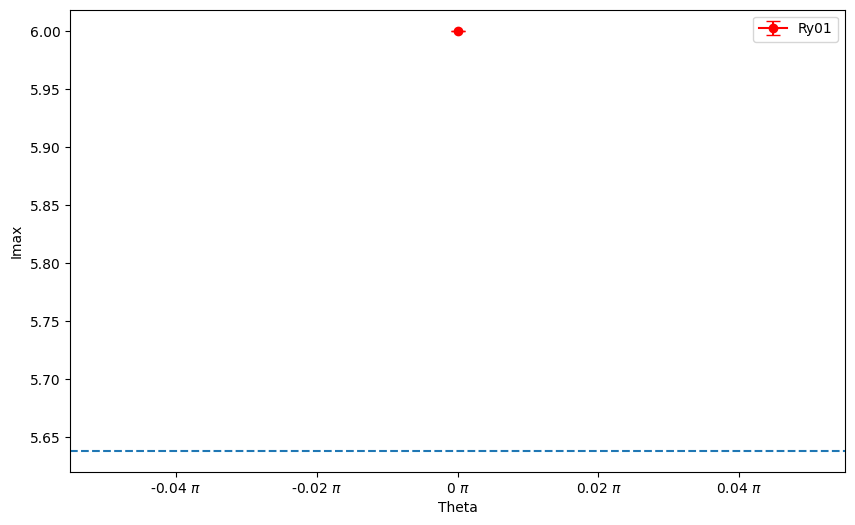

In [22]:
igvals, stds, thetas, listy = chsh(0*np.pi, 2*np.pi, 1, est, qtr2, 60, 2, session=False)

70
1 of 1, Jobs num: 1
1 of 1, Jobs num: 2
1 of 1, Jobs num: 3
End of session.
(6.177829534844512+0.04344251850624724j)


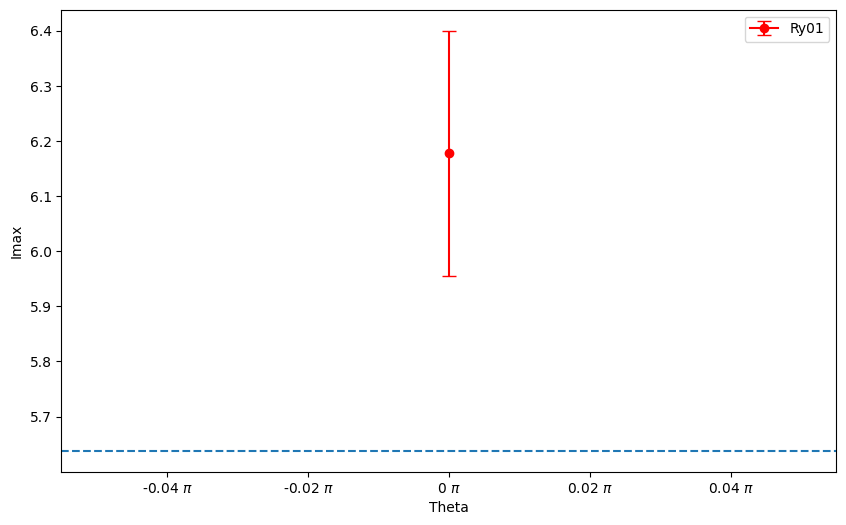

In [23]:
igvals, stds, thetas, listy = chsh(0*np.pi, 2*np.pi, 1, est, qtr2, 60, 3, session=True)

70
1 of 1, Jobs num: 1
1 of 1, Jobs num: 2
1 of 1, Jobs num: 3
End of session.
(5.904769669786033+0.06038277017260586j)


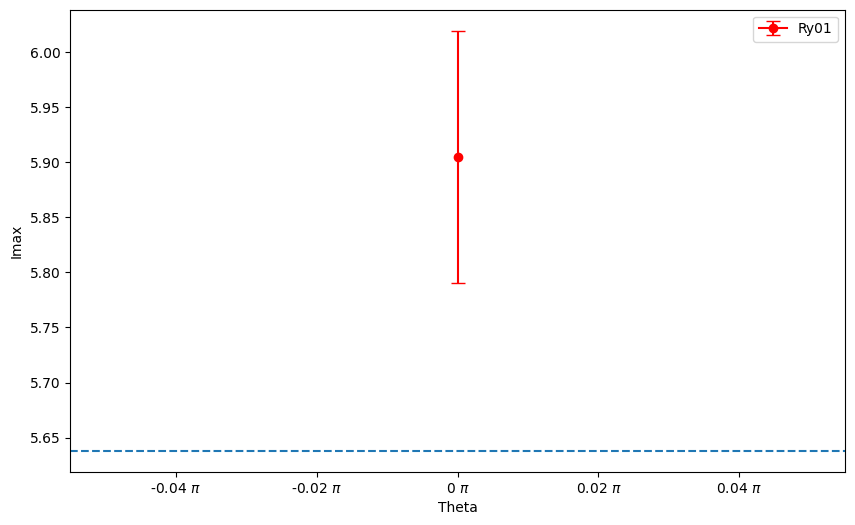

In [26]:
igvals, stds, thetas, listy = chsh(0*np.pi, 2*np.pi, 1, est, qtr2, 60, 3, session=True)

In [ ]:
igvals, stds, thetas = chsh(2*np.pi, 6*np.pi, 20, est, qtr2, pm)

In [ ]:
igvals, stds, thetas = chsh(2*np.pi, 6*np.pi, 11, est, qtr2, pm, session=True)

In [ ]:
parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list, theta_list = chsh(3.5*np.pi, 4.5*np.pi, 5, est, qtr2, 60, 3, session=True)

In [ ]:
parts_list

In [ ]:
igval_list, stds_list = chsh_results(parts_list, n_list_list, m_list_list, ncc_list_list, mcc_list_list)

In [ ]:
chsh_plot(igval_list, stds_list, theta_list)